# Import Library


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import Huber
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from datetime import datetime


# Data Understanding


In [2]:
df = pd.read_csv('DataProduksi.csv')
df


,Tanggal,Minyak Sawit,Karet Kering,Teh
0,Jan-09,1427.10,50.00,8.80
1,Feb-09,1188.00,45.50,7.90
2,Mar-09,1346.70,40.10,8.50
3,Apr-09,1193.50,38.80,9.30
4,May-09,1239.50,47.20,10.30
...,...,...,...,...
115,Aug-18,2075.95,35.32,5.99
116,Sep-18,2093.69,49.37,6.78
117,Oct-18,2075.70,51.21,8.12
118,Nov-18,1931.94,48.77,8.48


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tanggal       120 non-null    object 
 1   Minyak Sawit  120 non-null    float64
 2   Karet Kering  120 non-null    float64
 3   Teh           120 non-null    float64
dtypes: float64(3), object(1)
memory usage: 3.9+ KB


# Preprocessing


## Change date format


In [4]:
df['Tanggal'] = pd.to_datetime(
    df['Tanggal'], format='%b-%y').dt.strftime('%Y-%m')
df.head()


,Tanggal,Minyak Sawit,Karet Kering,Teh
0,2009-01,1427.1,50.0,8.8
1,2009-02,1188.0,45.5,7.9
2,2009-03,1346.7,40.1,8.5
3,2009-04,1193.5,38.8,9.3
4,2009-05,1239.5,47.2,10.3


In [5]:
df.to_csv('data_produksi_clean.csv', index=False)

In [6]:
df = pd.read_csv('data_produksi_clean.csv', parse_dates=['Tanggal'], index_col='Tanggal')
df

,Minyak Sawit,Karet Kering,Teh
Tanggal,,,
2009-01-01,1427.10,50.00,8.80
2009-02-01,1188.00,45.50,7.90
2009-03-01,1346.70,40.10,8.50
2009-04-01,1193.50,38.80,9.30
2009-05-01,1239.50,47.20,10.30
...,...,...,...
2018-08-01,2075.95,35.32,5.99
2018-09-01,2093.69,49.37,6.78
2018-10-01,2075.70,51.21,8.12


## Separating DataFrame Columns into Separate Variables


In [7]:
dates = df.index.values.reshape(-1,1)
minyak_sawit = df['Minyak Sawit'].values
karet_kering = df['Karet Kering'].values
teh = df['Teh'].values


## Windowed Dataset


In [8]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda w: (w[:-1], w[-1:]))
    return ds.batch(batch_size).prefetch(1)


## Split Dataset


In [9]:
def split_data(data, n_split):
    tscv = TimeSeriesSplit(n_splits=n_split)
    for train_index, test_index in tscv.split(dates):
        print("TRAIN:", train_index, "TEST:", test_index)
        X_train, X_test = dates[train_index], dates[test_index]
        y_train, y_test = data[train_index], data[test_index]
        return X_train, X_test, y_train, y_test


## Normalization


In [10]:
scaler = MinMaxScaler()
def normalization(data):
    return scaler.fit_transform(data)


def to_original_value(data):
    return scaler.inverse_transform(data)


# Generate Output


## Generate MAE & R2


In [11]:
def generate_mae_r2(X_test, y_pred):
    print('Mean Absolute Error:', mean_absolute_error(X_test, y_pred))
    print('R2 Score:', r2_score(X_test, y_pred))


## Generate Plot for Data test and Prediction


In [12]:
def generate_plot(X_data, y_data, X_name, y_name, attribute_name):
    plt.figure(figsize=(10, 6))
    plt.plot(X_data, label=X_name)
    plt.plot(y_data, label=y_name)
    plt.title(f'{X_name} vs {y_name} {attribute_name}')
    plt.xlabel('Bulan')
    plt.ylabel('Nilai Produksi')
    plt.legend()
    plt.show()
    print('\n')


# LSTM model


In [13]:
# def model_lstm(data, attribute_name, split_percentage=0.8, epochs=50):
#     X_train, X_test = split_data(normalization(data), split_percentage)
#     window_size = 12
#     batch_size = 32
#     shuffle_buffer_size = 1000

#     train_set = windowed_dataset(X_train, window_size, batch_size, shuffle_buffer_size)
#     test_set = windowed_dataset(X_train, window_size, batch_size, shuffle_buffer_size)

#     model = Sequential([
#         LSTM(128, return_sequences=True),
#         Dropout(0.2),
#         LSTM(64, return_sequences=True),
#         Dropout(0.2),
#         LSTM(32),
#         Dropout(0.2),
#         Dense(1),
#         Dropout(0.2)
#     ])

#     model.compile(loss=Huber(), optimizer=SGD(learning_rate=1e-5, momentum=0.9), metrics=['mae'])
#     model.fit(train_set, epochs=epochs, verbose=0)


# LSTM Evaluation


## Minyak Sawit


In [14]:
# model_lstm(minyak_sawit, 'Minyak Sawit', 0.8, 5)


## Karet Kering


In [15]:
# model_lstm(karet_kering, 'Karet Kering', 0.8, 50)


## Teh


In [16]:
# model_lstm(teh, 'Teh', 0.8, 50)


# SVR Model


In [17]:
def model_svr(data, attribute_name, n_split=3, c=1000, gamma='scale', epsilon=0.1):
    X_train, X_test, y_train, y_test = split_data(normalization(data.reshape(-1, 1)), n_split)
    model = make_pipeline(SVR(C=c, gamma=gamma, epsilon=epsilon))
    model.fit(X_train, y_train.ravel())
    y_pred = model.predict(X_test)
    generate_mae_r2(y_test, y_pred)
    generate_plot(to_original_value(y_test.reshape(-1,1)), to_original_value(y_pred.reshape(-1,1)), 'Data Test', 'Data Prediksi', attribute_name)
    generate_plot(to_original_value(y_train.reshape(-1,1)), to_original_value(y_pred.reshape(-1,1)), 'Data Training','Data Prediksi', attribute_name)


# SVR Evaluation


## Minyak Sawit


TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] TEST: [20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Mean Absolute Error: 0.14953546228663245
R2 Score: -0.27604246159142787


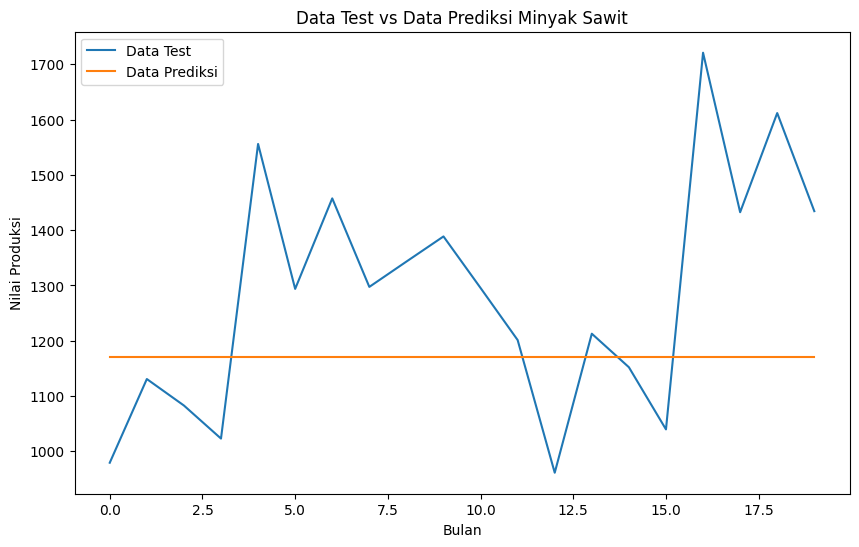

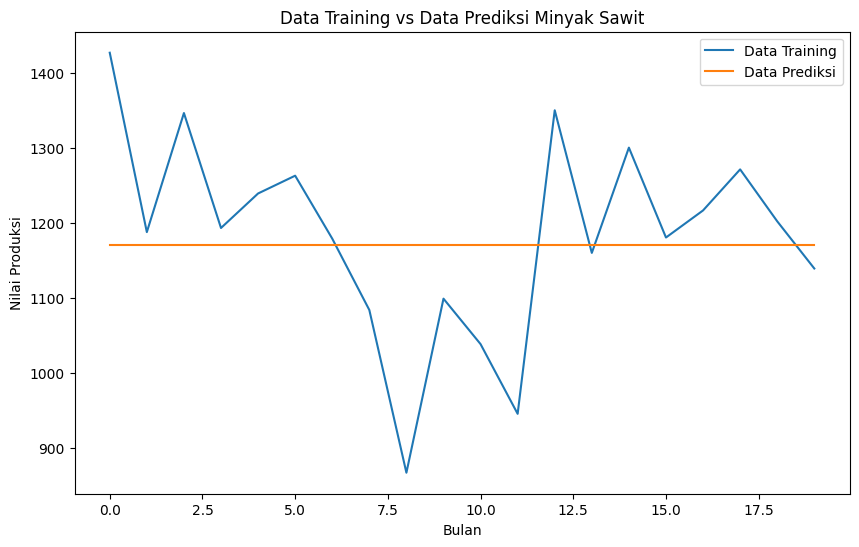



[0.23533097]


In [18]:
model_svr(minyak_sawit, 'Minyak Sawit', 5, 0.1, 'auto', 0.1)


## Karet Kering


TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] TEST: [20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Mean Absolute Error: 0.15712136229336393
R2 Score: -3.370452202777166


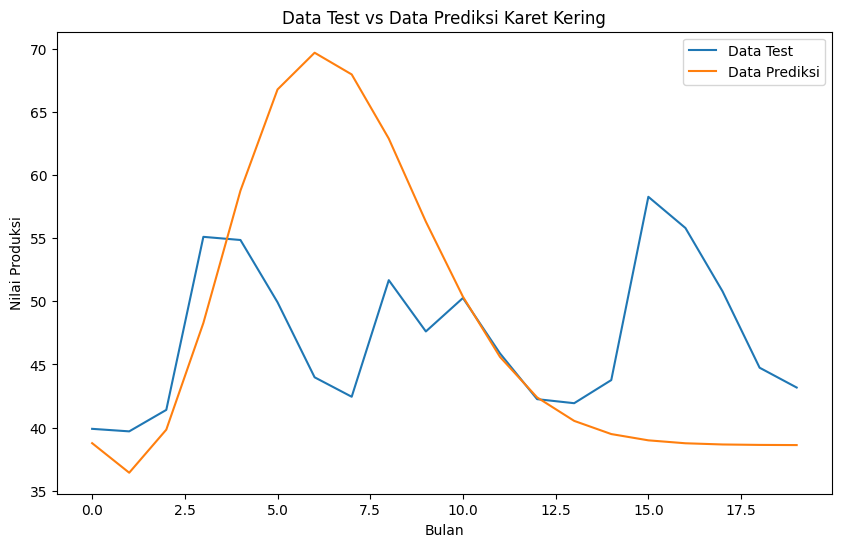

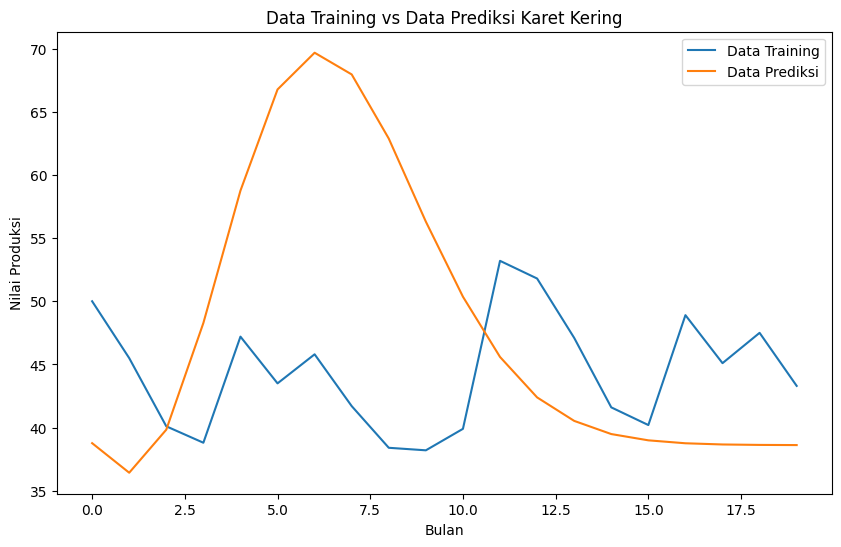



[0.14065527]


In [19]:
model_svr(karet_kering, 'Karet Kering', 5, 1000, 'scale', .01)


## Teh


TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] TEST: [20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Mean Absolute Error: 3.0141800225941697
R2 Score: -709.7414501433445


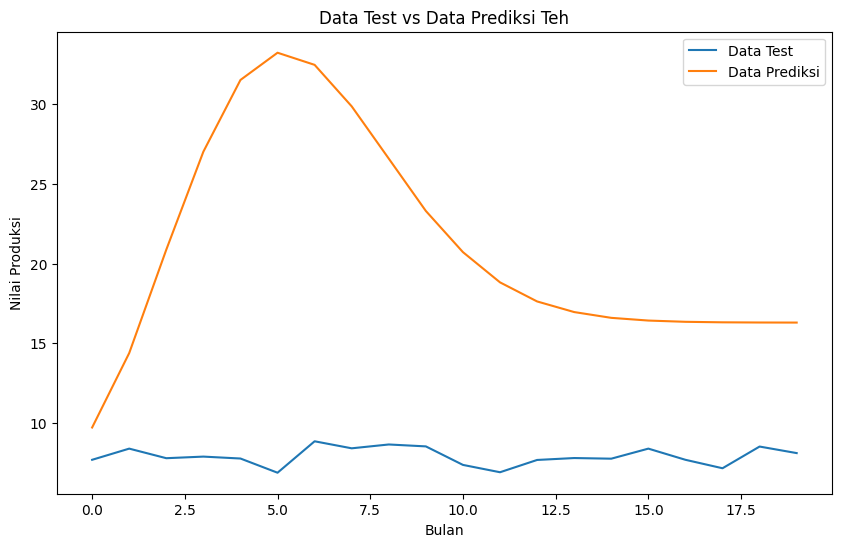

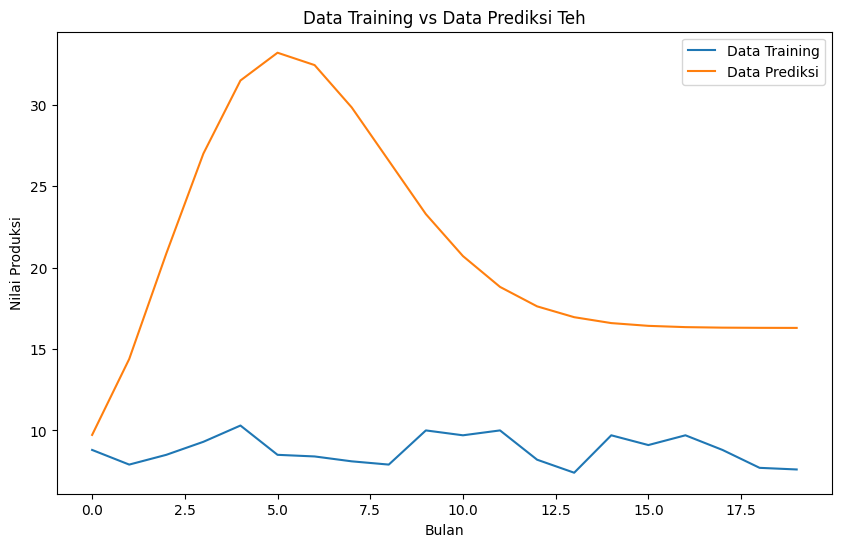



[2.37551899]


In [20]:
model_svr(teh, 'Teh', 5, 1000, 'scale', .01)
